<h1 align="center">SMS Spam Classification Using Naive Bayes</h1>

### Dataset Credits
This dataset is taken from UCI Machine Learning Respository: https://archive.ics.uci.edu/dataset/228/sms+spam+collection

Refer to dataset_credits_readme.txt file for credits details.

In [21]:
import pandas as pd

### Data Load and EDA

In [22]:
df = pd.read_csv("spam.csv")
print(df.shape)
df.head()

(5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Train test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.Message,df.Category, test_size = 0.2, random_state=5)

### Feature Engineering: Convert Text into Vector

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
X_train_count = v.fit_transform(X_train)
X_test_count = v.transform(X_test)

### Train a Model Using Naive Bayes

In [25]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_count ,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Model Evaluation: Precision, Recall and F1-Score

In [27]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_count)
report = classification_report(y_test ,y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



### Model Evaluation: Confusion Matrix

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test ,y_pred)
cm

array([[967,   3],
       [  6, 139]])

### Confusion matrix Visualization

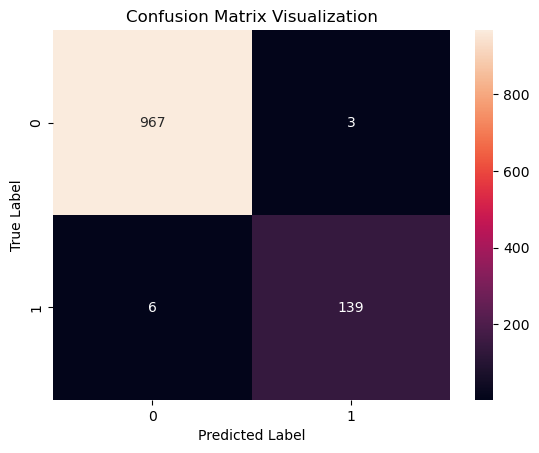

In [32]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.heatmap(cm ,annot=True , fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')
plt.show()

### Prediction on Sample Emails

In [36]:
emails = [
    'Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]
emails_count = v.transform(emails)
model.predict(emails_count)

array(['ham', 'spam'], dtype='<U4')